<a href="https://colab.research.google.com/github/JakeOh/202605_BD57/blob/main/lab_ml/ml07_grandient_descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gradient Descent(경사하강법)

*   머신러닝의 목적은 손실(비용) 함수를 최소로 만들 수 있는 모델 파라미터(w0, w1, w2, ...)들을 찾는 것.
*   회귀 문제에서 손실 함수는 MSE(w)
    *   w에 대한 2차 함수의 최솟값의 위치를 찾는 문제.
*   경사 하강법: 함수의 최솟값의 위치를 찾는 알고리즘 중의 하나.
    *   함수의 임의의 위치 w에서 시작.
    *   그 위치에서 접선의 기울기(gradient) 계산.
    *   gradient의 절댓값이 줄어드는 방향으로 w 값을 약간 수정.
    *   위의 과정을 충분히 반복하면 함수가 최소가 되는 위치를 찾을 수 있음.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

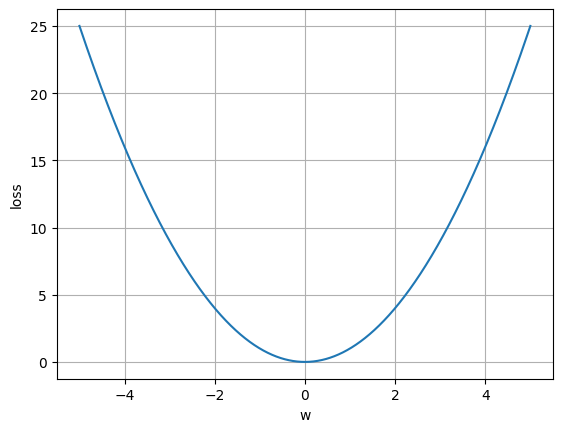

In [2]:
w = np.arange(-5, 5, 0.0001)
fn = w ** 2
plt.plot(w, fn)
plt.grid()
plt.xlabel('w')
plt.ylabel('loss')
plt.show()

In [5]:
# 임의의 w에서 시작
w_init = -4

# w_init 위치에서 gradient(접선의 기울기)를 계산
gradient = 2 * w_init

# 경사가 줄어드는 방향으로 약간 이동
w_next = w_init - gradient * 0.1

print(w_next)

-3.2


In [6]:
# 이동한 위치에서 다시 시작
w_init = w_next

# 다시 시작하는 위치에서 gradient를 계산
gradient = 2 * w_init

# 경사가 줄어드는 방향으로 약간 이동
w_next = w_init - gradient * 0.1

print(w_next)

-2.56


In [13]:
def gradient_descent(learning_rate=0.1, max_iter=50, tolerance=0.0001):
    # 2차 함수 f(w) = w^2 시각화
    w = np.arange(-5, 5, 0.0001)
    fn = w ** 2
    plt.plot(w, fn, color='DarkGray')

    # 임의의 w에서 시작.
    w_init = -4
    # 시작점의 위치를 점으로 표시
    plt.scatter(w_init, w_init ** 2, label='0')

    convergence = False
    for n in range(max_iter):
        # 시작점의 위치에서 경사(gradient)를 계산
        gradient = 2 * w_init  # 2차 함수 접선의 기울기 공식

        # 경사가 줄어드는 방향으로 시작점의 위치를 약간 이동
        w_next = w_init - gradient * learning_rate

        # 이동한 점의 위치를 점으로 표시
        plt.scatter(w_next, w_next ** 2, label=f'{n + 1}')

        # 반복(iteration)을 계속 할 지, 아니면 멈출 지를 결정하기 위해서
        # 이동한 위치 w_next와 이동하기 전 위치 w_init 사이의 거리가
        # tolerance보다 작은 지를 검사.
        if np.abs(w_next - w_init) < tolerance:
            convergence = True
            break  # for 반복문을 멈춤.

        # 그 다음 반복(iteration)을 시작하기 전에 시작 위치를 이동한 위치로 변경
        w_init = w_next

    print(f'최솟값의 위치 w = {w_next}')
    if convergence == False:
        print('ConvergenceWarning: 찾은 w는 정확한 최솟값이 아닐 수 있음.')

    plt.grid()
    plt.legend()
    plt.xlabel('w')
    plt.ylabel('fn')
    plt.show()

최솟값의 위치 w = -0.0003402823669209386


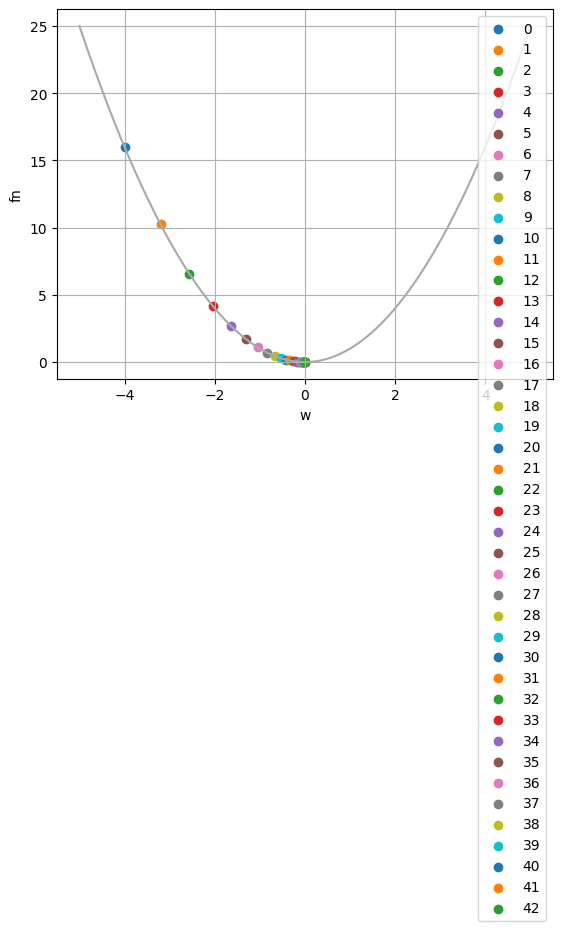

In [14]:
gradient_descent()

최솟값의 위치 w = -5.7089907708238416e-05


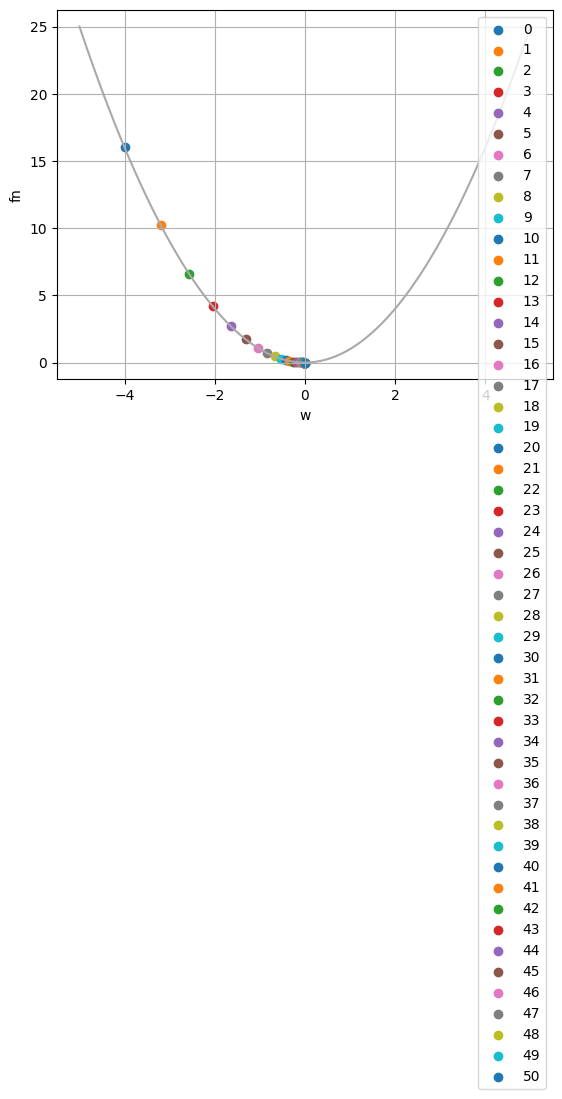

In [15]:
gradient_descent(tolerance=0.00001)

최솟값의 위치 w = -0.003961408125713218


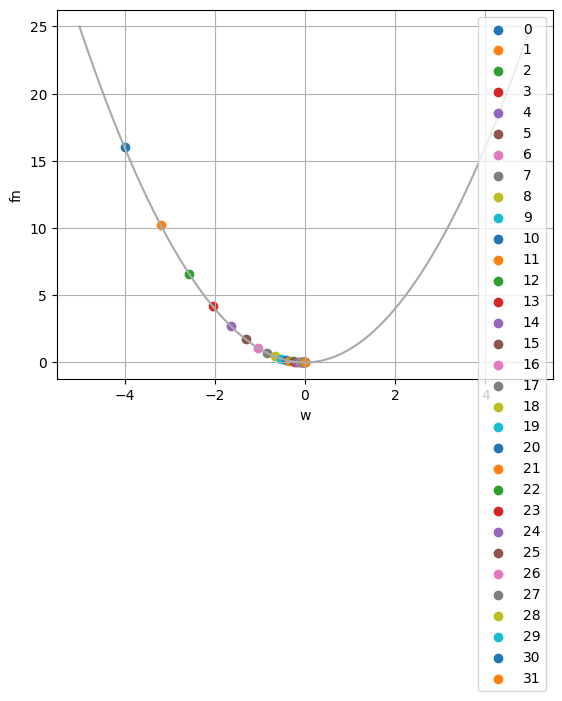

In [16]:
gradient_descent(tolerance=0.001)

최솟값의 위치 w = -3.653754093327259e-05


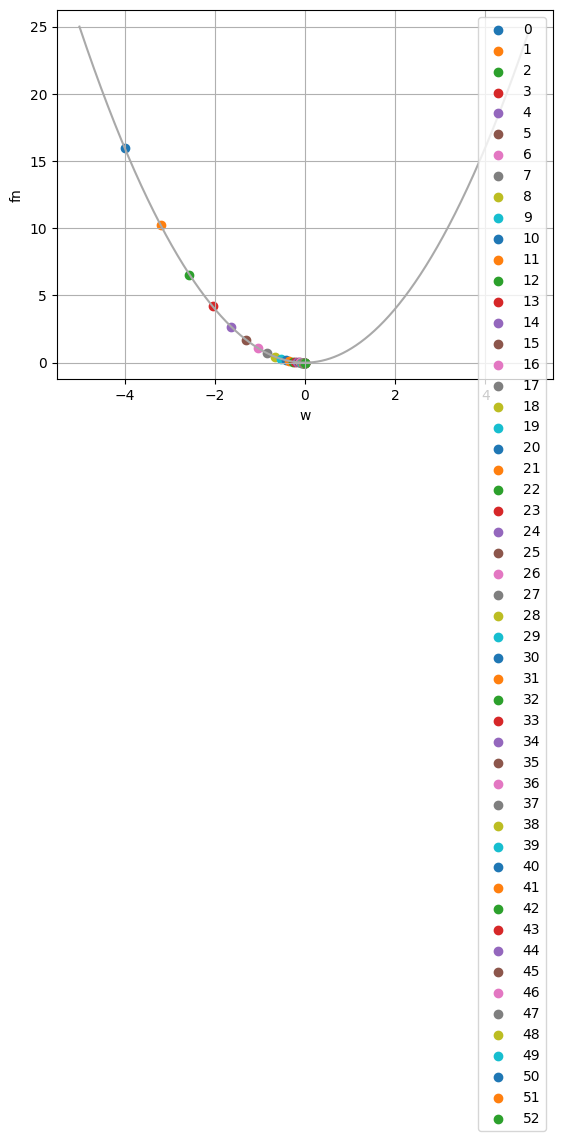

In [18]:
gradient_descent(max_iter=1_000, tolerance=0.00001)

머신러닝 모델 훈련 과정에서 ConvergenceWarning이 발생하는 경우, max_iter 파라미터 값을 더 크게 하거나 또는 더 큰 tolerance 값을 사용하면 경고를 없앨 수도 있음.